# 06 — How finely must the match line resolve?

Every notebook so far has picked $\tau$ by eye. This one asks the question a circuit designer
actually needs answered:

> The sense amplifier compares a match-line quantity against a threshold. **One part in how
> many** must it resolve before acquisition falls apart?

This is the architecture's central hardware question, and the answer is uncomfortable — for a
reason notebook 03 already exposed.

By the end you should be able to answer:

1. Why is GNSS a fundamentally harder sensing problem than the BLE study on the same hardware?
2. How do you even *define* "required resolution" operationally?
3. Does segmentation help? (yes — for a second reason, independent of the Doppler-row saving)
4. What does the answer mean in bits of ADC on the match line?

Module: [`sim/gps/sense_margin_study.py`](../sim/gps/sense_margin_study.py).
Published result: [`figures/gps_sense_margin.md`](../figures/gps_sense_margin.md).

In [1]:
import sys, pathlib, math
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sim.gps.experiments import GpsConfig, cached_distances, dwells_required, independent_cells
from sim.gps.sense_margin_study import run as sense_run, SEGMENTS, CN0S

# sim/plots.py calls matplotlib.use("Agg") at import time, which the study modules
# pull in. Restore the inline backend so figures render in the notebook.
%matplotlib inline

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
TRIALS, SEED = 3000, 42

---
## 1. Where the operating point actually sits

Notebook 03 measured it: the aligned row sits **2.2% below chance** at 38 dB-Hz. Let's look at
what that means as a *sensing* requirement rather than a statistics one.

In [2]:
d = cached_distances(GpsConfig(n_segments=1, n_prn=3), 38.0, TRIALS, SEED)
al = d["aligned"].ravel()
wr = np.concatenate([d[k].ravel() for k in ("wrong_phase", "wrong_doppler", "wrong_prn")])
W = 4092

print(f"match line width W          : {W} bits")
print(f"chance (W/2)                : {W//2}")
print(f"aligned cell, mean distance : {al.mean():.0f}   ({(0.5-al.mean()/W)*100:.2f}% below chance)")
print(f"wrong cell,   mean distance : {wr.mean():.0f}")
print(f"separation                  : {wr.mean()-al.mean():.0f} bits "
      f"= {(wr.mean()-al.mean())/W*100:.2f}% of the match line")
print()
print("So the sense amp must reliably distinguish two populations whose means differ by")
print(f"~{(wr.mean()-al.mean())/W*100:.1f}% of the full-scale match-line swing.")

match line width W          : 4092 bits
chance (W/2)                : 2046
aligned cell, mean distance : 1959   (2.13% below chance)
wrong cell,   mean distance : 2010
separation                  : 51 bits = 1.24% of the match line

So the sense amp must reliably distinguish two populations whose means differ by
~1.2% of the full-scale match-line swing.


### Why this is worse than the BLE study on identical hardware

In the BLE work a match sits at roughly **23% of $W$** — 27 points below chance, a huge,
comfortable gap. Here it is 1–2 points. Same CAM, same sense amplifier, wildly different ask.

The reason is structural, not incidental. GNSS spreads its processing gain *thinly*: 4092 bits
each carrying a 2% bias, versus BLE's short key where each bit is strongly informative. The
total evidence is comparable; its **concentration per bit** is not.

> This is the honest statement of the architecture's difficulty. The CAM is not being asked to
> do something slightly harder here — it is being asked to resolve a signal an order of
> magnitude finer, on the same match line.

---
## 2. Defining "required resolution" operationally

"How much $\tau$ error is tolerable" is meaningless without a criterion. The study uses a
practical one:

> **The width of the $\tau$ band over which acquisition stays within 10% of its best dwell
> count**, expressed as a fraction of the segment width.

A circuit designer reads the reciprocal directly: *"the match line must resolve one part in
$N$."* Below, the dwell count as a function of $\tau$ — the basin, and how wide its floor is.

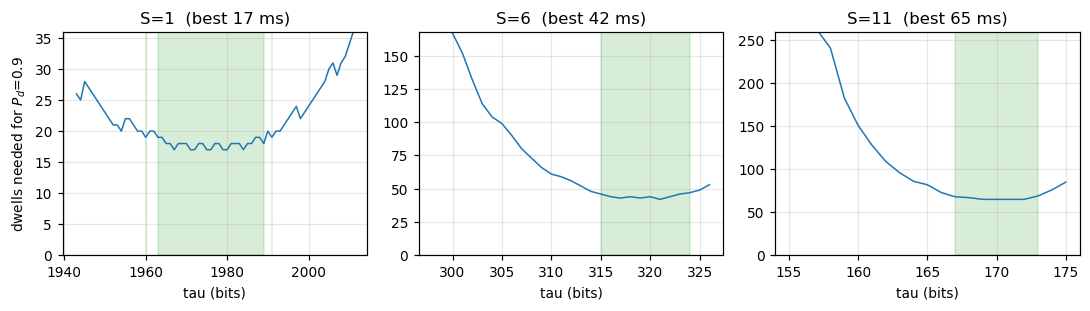

Shaded = the tau band within 10% of best. That band's width IS the answer.


In [3]:
def dwells_vs_tau(S, cn0, trials=TRIALS, seed=SEED):
    cfg = GpsConfig(n_segments=S, n_prn=3)
    cells = independent_cells(GpsConfig(n_segments=S, n_prn=32))
    i = SEGMENTS.index(S); j = CN0S.index(cn0)
    dd = cached_distances(cfg, cn0, trials, seed + 1000 * i + j)
    a = dd["aligned"].ravel()
    w = np.concatenate([dd[k].ravel() for k in ("wrong_phase", "wrong_doppler", "wrong_prn")])
    taus = np.arange(int(np.quantile(w, 0.002)), int(np.quantile(w, 0.5)))
    out = []
    for t in taus:
        p1, p0 = (a <= t).mean(), (w <= t).mean()
        m, _ = dwells_required(p1, p0, int(S), cells) if 0 < p0 < p1 else (-1, -1)
        out.append(m if m > 0 else np.nan)
    return taus, np.array(out, dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.9))
for ax, S in zip(axes, [1, 6, 11]):
    taus, m = dwells_vs_tau(S, 38.0)
    best = np.nanmin(m)
    ok = m <= np.ceil(1.1 * best)
    ax.plot(taus, m, lw=1)
    ax.fill_between(taus, 0, 1, where=ok, transform=ax.get_xaxis_transform(),
                    color="C2", alpha=0.18)
    ax.set(title=f"S={S}  (best {int(best)} ms)", xlabel="tau (bits)",
           ylim=(0, min(np.nanmax(m), 4 * best)))
axes[0].set_ylabel("dwells needed for $P_d$=0.9")
plt.tight_layout(); plt.show()
print("Shaded = the tau band within 10% of best. That band's width IS the answer.")

Note the shape: the basin is **asymmetric**. Too tight a $\tau$ and $p_1$ collapses (the
correct row stops firing); too loose and $p_0$ explodes into the chance pile of notebook 03.
The floor between them is narrow, and it is narrow in *absolute bits*.

---
## 3. The answer

[`sense_margin_study.run`](../sim/gps/sense_margin_study.py) does the sweep for every $S$ and
both operating C/N0 values.

In [4]:
res = sense_run(trials=TRIALS, seed=SEED)

print(f"{'S':>3} {'seg width':>10} {'tau band @38':>14} {'width':>7} {'resolution':>16}")
for i, S in enumerate(res["segments"]):
    lo, hi = res["tau_lo"][i, 0], res["tau_hi"][i, 0]
    frac = res["tolerance_frac"][i, 0]
    print(f"{S:>3} {res['seg_width'][i]:>7} bits {f'{lo}-{hi}':>14} {hi-lo+1:>4} b "
          f"{f'1 part in {1/frac:.0f}':>16}")

  S  seg width   tau band @38   width       resolution
  1    4092 bits      1960-1991   32 b    1 part in 128
  2    2046 bits        970-992   23 b     1 part in 89
  3    1364 bits        643-656   14 b     1 part in 97
  6     682 bits        315-324   10 b     1 part in 68
 11     372 bits        167-173    7 b     1 part in 53


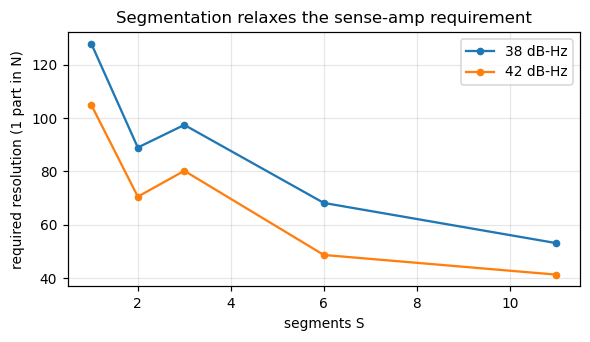

required resolution, S=1 -> S=11:
  38 dB-Hz: 1 part in 128  ->  1 part in 53   (2.4x easier)
  42 dB-Hz: 1 part in 105  ->  1 part in 41   (2.5x easier)


In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
for j, cn0 in enumerate(res["cn0s"]):
    ax.plot(res["segments"], 1 / res["tolerance_frac"][:, j], "o-", ms=4,
            label=f"{cn0:.0f} dB-Hz")
ax.set(xlabel="segments S", ylabel="required resolution (1 part in N)",
       title="Segmentation relaxes the sense-amp requirement")
ax.legend(); plt.show()

print("required resolution, S=1 -> S=11:")
for j, cn0 in enumerate(res["cn0s"]):
    r = 1 / res["tolerance_frac"][:, j]
    print(f"  {cn0:.0f} dB-Hz: 1 part in {r[0]:.0f}  ->  1 part in {r[-1]:.0f}"
          f"   ({r[0]/r[-1]:.1f}x easier)")

### Segmentation helps for a *second*, independent reason

Notebook 05 justified segmentation by the Doppler-row saving: shorter $T_{\text{coh}}$, fewer
rows, smaller dictionary. This is a different argument entirely, and it points the same way:

**A shorter sub-line is easier to resolve.** The required precision improves from 1 part in
128 to 1 part in 53 going from $S=1$ to $S=11$ — because the tolerable $\tau$ band, while
narrower in absolute bits (32 → 7), shrinks *more slowly* than the segment width does
(4092 → 372).

So the two arguments for segmentation are independent, and both favour it. What opposes it is
the sensitivity cost measured in notebook 05. Notebook 07 puts all three on one axis.

In [6]:
print(f"{'S':>3} {'seg width':>10} {'band (bits)':>12} {'band as % of width':>20}")
for i, S in enumerate(res["segments"]):
    w = res["seg_width"][i]; b = res["tau_hi"][i, 0] - res["tau_lo"][i, 0] + 1
    print(f"{S:>3} {w:>7} bits {b:>9} b {b/w*100:>17.2f} %")
print("\nAbsolute band narrows 32 -> 7 bits, but relative tolerance LOOSENS 0.78% -> 1.88%.")

  S  seg width  band (bits)   band as % of width
  1    4092 bits        32 b              0.78 %
  2    2046 bits        23 b              1.12 %
  3    1364 bits        14 b              1.03 %
  6     682 bits        10 b              1.47 %
 11     372 bits         7 b              1.88 %

Absolute band narrows 32 -> 7 bits, but relative tolerance LOOSENS 0.78% -> 1.88%.


---
## 4. What this means in hardware

"1 part in $N$" on a match line converts directly to an effective resolution requirement:

$$ \text{bits of match-line resolution} \;=\; \log_2 N $$

In [7]:
print(f"{'S':>3} {'C/N0':>7} {'resolution':>16} {'effective bits':>15}")
for i, S in enumerate(res["segments"]):
    for j, cn0 in enumerate(res["cn0s"]):
        n = 1 / res["tolerance_frac"][i, j]
        print(f"{S:>3} {cn0:>5.0f}   {f'1 part in {n:.0f}':>16} {math.log2(n):>14.1f}")

  S    C/N0       resolution  effective bits
  1    38      1 part in 128            7.0
  1    42      1 part in 105            6.7
  2    38       1 part in 89            6.5
  2    42       1 part in 71            6.1
  3    38       1 part in 97            6.6
  3    42       1 part in 80            6.3
  6    38       1 part in 68            6.1
  6    42       1 part in 49            5.6
 11    38       1 part in 53            5.7
 11    42       1 part in 41            5.4


So the array needs roughly **6–7 bits** of effective resolution on the match line at $S=1$,
easing to **5–6 bits** at $S=11$.

Two things worth saying plainly about that number:

- It is *not* extreme. A 6–7 bit sense operation is well within what analog match-line designs
  achieve. This is the good news, and it is what makes the architecture plausible at all.
- It is *not* free either. It rules out the simplest possible sense amp — a single-ended
  comparator on a discharge line — and it means match-line non-idealities (process variation
  across a 4092-cell line, temperature drift, IR drop) have to hold to about 1%. On a
  4092-cell line that is a real design constraint, and it is a strong argument for segmenting
  even if the Doppler dictionary were free.

> **The honest summary:** the CAM does not need a converter, but it does need a *calibrated*
> comparator. That sits between the two things a paper might want to claim, and it is where
> this study actually lands.

---
## What we established

| Fact | Consequence |
|---|---|
| Aligned vs wrong cells differ by ~1–2% of the match line | GNSS is a far finer sensing task than the BLE study |
| Required resolution defined as the 10%-of-best $\tau$ band | a criterion a circuit designer can use |
| $S=1$: 1 part in 128 (38 dB-Hz), 1 part in 105 (42 dB-Hz) | ~7 bits of match-line resolution |
| $S=11$: 1 part in 53 → ~5.7 bits | segmentation eases sensing, independently of the row saving |
| Absolute band 32 → 7 bits, relative 0.78% → 1.88% | shorter lines are easier even though the band shrinks |
| Higher C/N0 needs *finer* resolution, not coarser | the basin narrows as the operating point improves |

## Next

**Notebook 07 — `dwells.ipynb`.** We have $p_1$ and $p_0$ per segment. Now turn them into the
number the whole project reports: **milliseconds to acquire**. That means the binomial
accumulation model over $M$ dwells, the false-alarm budget spread across 1.34 M cells, and
finally the area-vs-time Pareto curve that the segmentation trade traces out.

### Try it yourself
- The last table shows higher C/N0 requiring *finer* resolution. Explain why before re-deriving it.
- Re-run §2 with a 5% criterion instead of 10%. How much does the required resolution tighten?
- What happens to the required resolution with the `thermometer` mapping, where the match line is 3x wider but carries magnitude information?